In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [4]:
# Load parquet files
df_apr = pd.read_parquet("yellow_tripdata_2025-04.parquet")
df_may = pd.read_parquet("yellow_tripdata_2025-05.parquet")
df_jun = pd.read_parquet("yellow_tripdata_2025-06.parquet")

# Create new dataframe for visualization
df_viz = pd.concat([df_apr, df_may, df_jun], ignore_index=True)

print("Data Loaded:", df_viz.shape)
df_viz.head()

Data Loaded: (12885358, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-04-01 00:47:06,2025-04-01 01:13:25,1.0,9.50,1.0,N,138,230,1,38.7,11.00,0.5,11.65,6.94,1.0,69.79,2.5,1.75,0.75
1,2,2025-04-01 00:27:35,2025-04-01 00:38:19,2.0,3.77,1.0,N,138,92,1,17.0,6.00,0.5,4.90,0.00,1.0,31.15,0.0,1.75,0.00
2,2,2025-04-01 00:24:07,2025-04-01 00:35:12,1.0,5.41,1.0,N,132,130,1,22.6,1.00,0.5,5.37,0.00,1.0,32.22,0.0,1.75,0.00
3,1,2025-04-01 00:56:30,2025-04-01 01:00:49,2.0,0.60,1.0,N,79,4,1,6.5,4.25,0.5,2.45,0.00,1.0,14.70,2.5,0.00,0.75
4,2,2025-04-01 00:00:17,2025-04-01 00:16:19,1.0,0.43,1.0,N,161,229,2,4.4,1.00,0.5,0.00,0.00,1.0,10.15,2.5,0.00,0.75


## Data Loading

We combine April, May, and June datasets into a new dataframe `df_viz`.

This ensures:
- No modification of original data
- Independent analysis environment

In [5]:
df_viz = df_viz[
    (df_viz['trip_distance'] > 0) &
    (df_viz['fare_amount'] > 0) &
    (df_viz['total_amount'] > 0) &
    (df_viz['passenger_count'] > 0)
]

df_viz = df_viz[
    df_viz['tpep_dropoff_datetime'] > df_viz['tpep_pickup_datetime']
]

print("Cleaned Data:", df_viz.shape)

Cleaned Data: (9161338, 20)


## Act 2: Defining a Real Trip

We remove invalid trips:
- Zero or negative distance
- Invalid fares
- Incorrect timestamps

This ensures reliable analysis.

In [7]:
# Trip duration
df_viz['trip_duration'] = (
    df_viz['tpep_dropoff_datetime'] - df_viz['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Time features
df_viz['pickup_hour'] = df_viz['tpep_pickup_datetime'].dt.hour
df_viz['pickup_day'] = df_viz['tpep_pickup_datetime'].dt.day_name()

# Simulation
R = 5
df_viz['simulated_total'] = df_viz['total_amount'] * (1 + R/100)

In [8]:
print("Total Trips:", len(df_viz))
print("Avg Fare:", df_viz['total_amount'].mean())
print("Avg Tip:", df_viz['tip_amount'].mean())
print("Actual Revenue:", df_viz['total_amount'].sum())
print("Simulated Revenue:", df_viz['simulated_total'].sum())

Total Trips: 9161338
Avg Fare: 29.754931161801906
Avg Tip: 3.777127002627782
Actual Revenue: 272594981.53999996
Simulated Revenue: 286224730.617


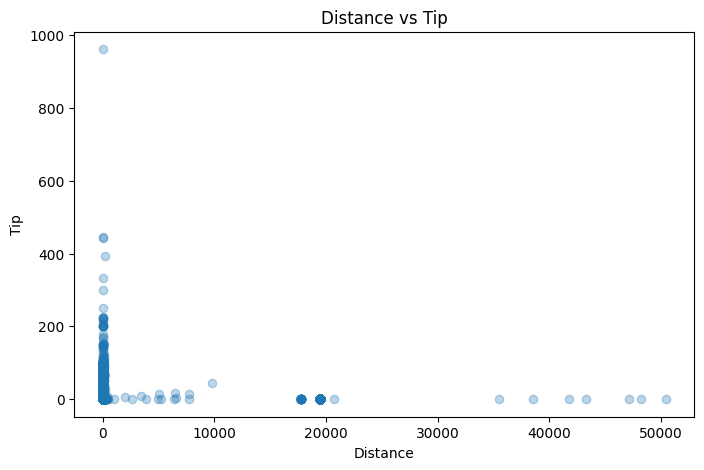

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df_viz['trip_distance'], df_viz['tip_amount'], alpha=0.3)
plt.title("Distance vs Tip")
plt.xlabel("Distance")
plt.ylabel("Tip")
plt.show()

## Act 3: Behavioral Analysis

There is a positive relationship between distance and tips.

However, variability suggests other influencing factors.

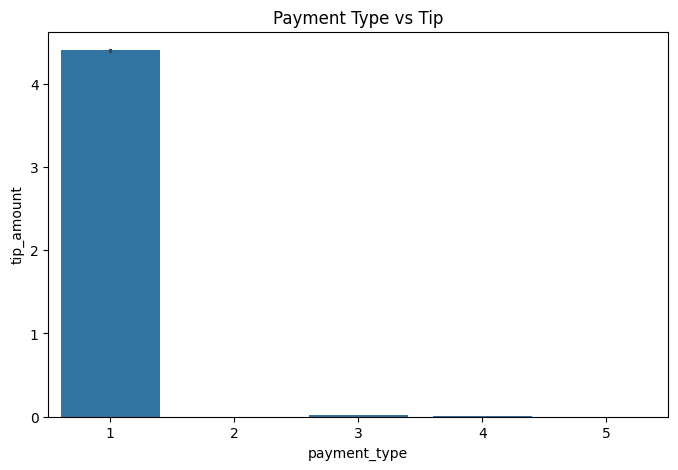

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x=df_viz['payment_type'], y=df_viz['tip_amount'])
plt.title("Payment Type vs Tip")
plt.show()

## Alternative Explanation

Payment type affects tipping behavior significantly.

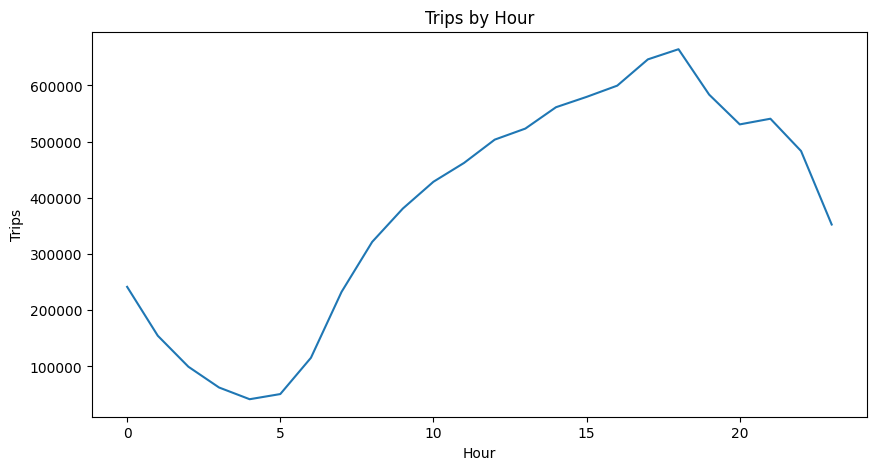

In [13]:
hourly_trips = df_viz.groupby('pickup_hour').size()

plt.figure(figsize=(10,5))
hourly_trips.plot()
plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

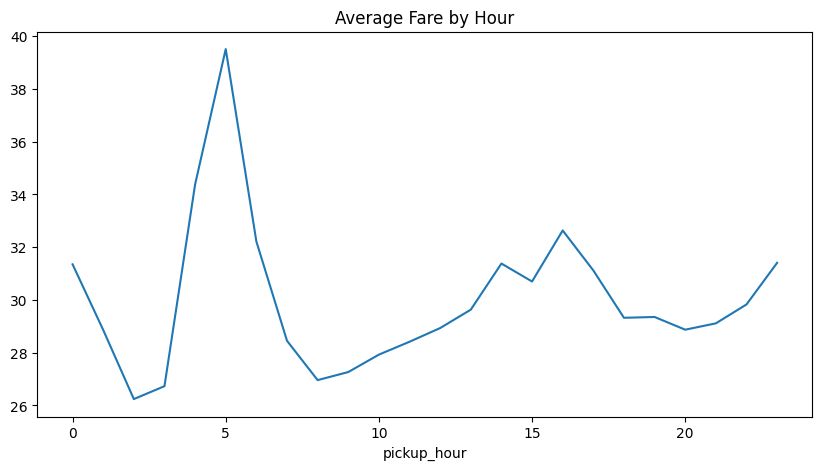

In [14]:
hourly_fare = df_viz.groupby('pickup_hour')['total_amount'].mean()

plt.figure(figsize=(10,5))
hourly_fare.plot()
plt.title("Average Fare by Hour")
plt.show()

## Act 4: System Patterns

Trips follow cyclical patterns with peak hours.

This indicates structured demand behavior.

In [15]:
peak_hour = hourly_trips.idxmax()
print("Peak Hour:", peak_hour)

Peak Hour: 18


## System Stress

High trip concentration at peak hours indicates system strain.

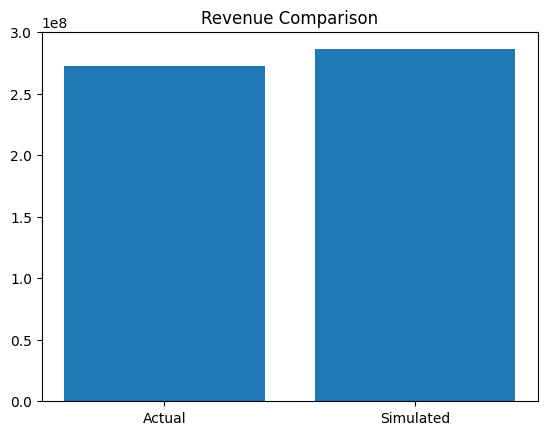

In [16]:
actual = df_viz['total_amount'].sum()
simulated = df_viz['simulated_total'].sum()

plt.bar(['Actual','Simulated'], [actual, simulated])
plt.title("Revenue Comparison")
plt.show()

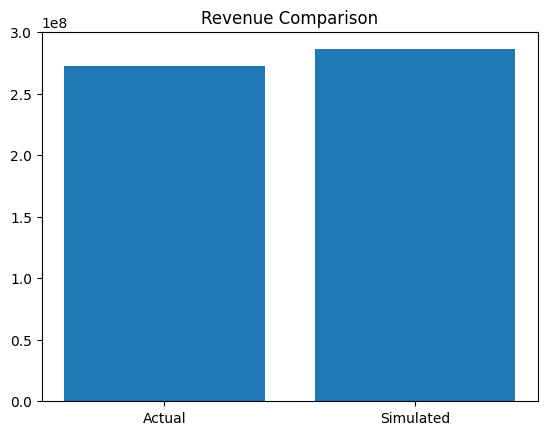

In [17]:
actual = df_viz['total_amount'].sum()
simulated = df_viz['simulated_total'].sum()

plt.bar(['Actual','Simulated'], [actual, simulated])
plt.title("Revenue Comparison")
plt.show()

<Figure size 1000x500 with 0 Axes>

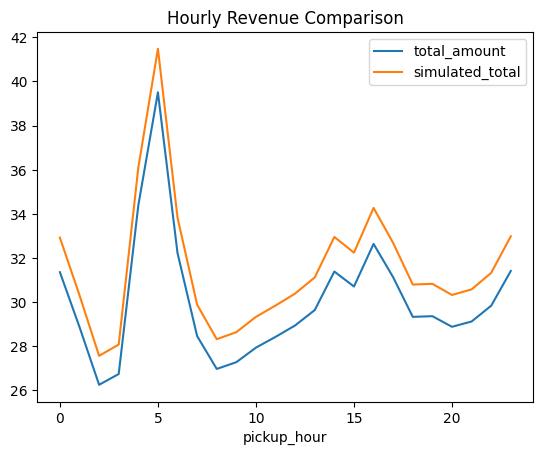

In [18]:
hourly_rev = df_viz.groupby('pickup_hour')[['total_amount','simulated_total']].mean()

plt.figure(figsize=(10,5))
hourly_rev.plot()
plt.title("Hourly Revenue Comparison")
plt.show()

## Act 5: Simulation

A 5% fare increase results in higher revenue.

The system appears stable under this change.

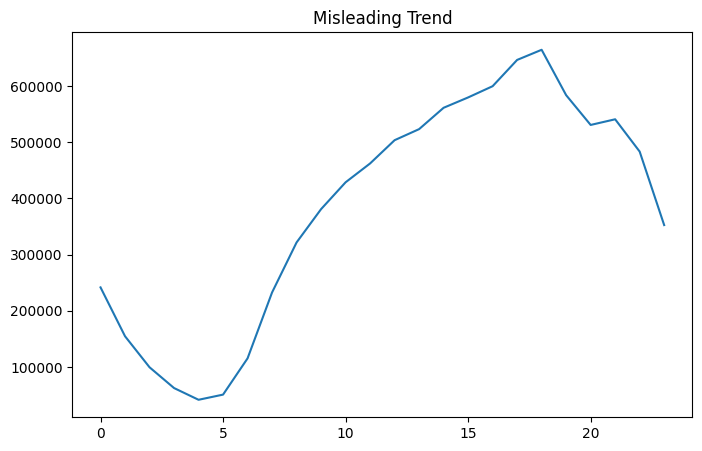

In [19]:
plt.figure(figsize=(8,5))
plt.plot(hourly_trips)
plt.title("Misleading Trend")
plt.show()

## Misinterpretation

Total trips alone suggest stability.

However, hourly distribution reveals peak stress.

## Final Conclusion

The system shows:
- Cyclical demand patterns
- Stable overall performance
- Stress during peak hours

Simulation indicates:
- Revenue increases with fare changes
- No immediate instability

Limitations:
- No external factors included
- Results depend on cleaning assumptions

Conclusion:
The system is stable but under pressure during peak periods.